# Multi-subject analysis

Most of the other examples deal with single-subject analysis for speed. Therefore, this example will demonstrate how to analyze a multi-subject dataset starting from a list of subject-specific epochs objects.

## Simulating data

We will simulate an experiment in which participants complete trials in one of two conditions. One condition will be associated with a frontally focused ERP an the other with a parietally focused ERP. First, we will set up the underlying ERP timecourse.

Text(0.5, 1.0, 'Underlying ERP timecourse')

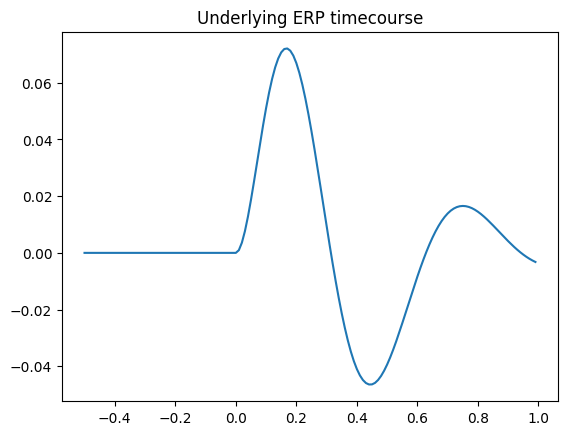

In [60]:
import mne
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import mne_plsc

np.random.seed(123)

# Set up underlying ERP timecourse
sfreq = 100
times = np.arange(-0.5, 1, 1/sfreq)
erp_timecourse = np.exp(-5*times) * times * np.sin(10*times)
erp_timecourse[times < 0] = 0
f, ax = plt.subplots()
ax.plot(times, erp_timecourse)
ax.set_title('Underlying ERP timecourse')

Next, we will set up the weights that will determine how strongly the ERP will be expressed at each channel in each condition.

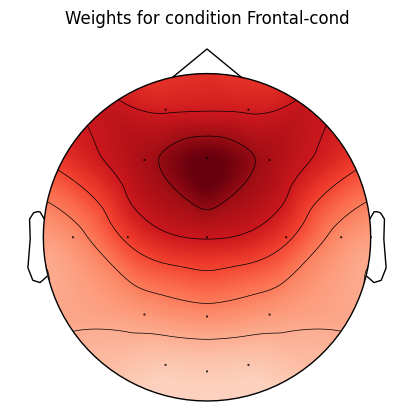

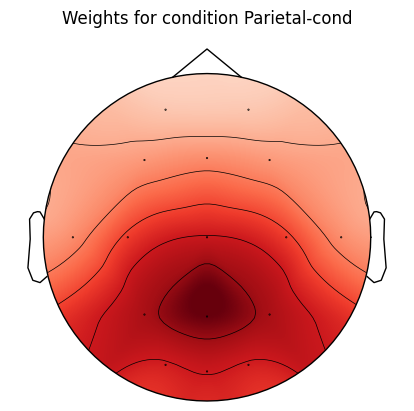

In [61]:
# Set up montage and info
montage = mne.channels.make_standard_montage('biosemi16')
ch_pos_dict = montage.get_positions()["ch_pos"]
ch_pos_array = np.array([ch_pos_dict[ch] for ch in montage.ch_names])
info = mne.create_info(ch_names=montage.ch_names,
                       ch_types='eeg',
                       sfreq=sfreq)
info = info.set_montage(montage)

# Function to get channel weights
def get_chan_weights(main_chan):
    center = ch_pos_dict[main_chan]
    dist = np.linalg.norm(ch_pos_array - center, axis=1)
    w = np.exp(-(dist ** 2) / (2 * 0.1 ** 2))
    return w

cond_weights = {
    'Frontal-cond': get_chan_weights('Fz'),
    'Parietal-cond': get_chan_weights('Pz')
}
for cond_name, weights in cond_weights.items():
    f, ax = plt.subplots()
    mne.viz.plot_topomap(weights, info, axes=ax, show=False)
    ax.set_title('Weights for condition %s' % cond_name)
    plt.show()

Finally, we will simulate the actual epochs per participant.

In [62]:
n_ptpts = 5
trials_per_cond = 5
event_id = {name: i + 1 for i, name in enumerate(cond_weights.keys())}
all_epochs = []
for ptpt_n in range(n_ptpts):
    condwise_data = []
    condwise_events = []
    condwise_metadata = []
    for cond_name, weights in cond_weights.items():
        # Compute data for this condition
        data = np.outer(weights, erp_timecourse)
        noise = 0.03*np.random.normal(size=(trials_per_cond, *data.shape))
        cond_data = data + noise
        condwise_data.append(cond_data)
        # Add events array
        cond_events = np.zeros((trials_per_cond, 3), dtype=np.int64)
        cond_events[:, 2] = event_id[cond_name]
        condwise_events.append(cond_events)
        # Add metadata
        cond_metadata = pd.DataFrame({'cond': [cond_name]*trials_per_cond})
        condwise_metadata.append(cond_metadata)
    # Combine conditions into epochs for this participant
    data = np.concat(condwise_data)
    events = np.concat(condwise_events)
    events[:, 0] = np.arange(len(events)) + 1
    metadata = pd.concat(condwise_metadata)
    epochs = mne.EpochsArray(data=data,
                             info=info,
                             events=events,
                             event_id=event_id,
                             metadata=metadata)
    all_epochs.append(epochs)

Adding metadata with 1 columns
10 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 1 columns
10 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 1 columns
10 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 1 columns
10 matching events found
No baseline correction applied
0 projection items activated
Adding metadata with 1 columns
10 matching events found
No baseline correction applied
0 projection items activated


## Setting up for model fitting

`all_epochs` is a list of participant-specific epochs objects. Each such object has labels that can be used to index them and which indicate the experimental condition:

In [63]:
print(all_epochs[0])
print(all_epochs[0]['Frontal-cond'])

<EpochsArray | 10 events (all good), 0 – 1.49 s (baseline off), ~210 KiB, data loaded, with metadata,
 'Frontal-cond': 5
 'Parietal-cond': 5>
<EpochsArray | 5 events (all good), 0 – 1.49 s (baseline off), ~117 KiB, data loaded, with metadata,
 'Frontal-cond': 5>


For model fitting, we need averages per condition, per subject. One way is to compute averages per epoch label:

In [64]:
evoked_list, design = mne_plsc.utils.average_epochs_by_label(all_epochs)

`evoked_list` is a list of `mne.Evoked` objects, each containing one participant's average response in a given condition. `design` is a dataframe telling us the participant ID and within-participants condition of each element of `evoked_list`:

In [65]:
print(evoked_list)
design

[<Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>]


,within,participant
0,Parietal-cond,0
1,Frontal-cond,0
2,Parietal-cond,1
3,Frontal-cond,1
4,Parietal-cond,2
5,Frontal-cond,2
6,Parietal-cond,3
7,Frontal-cond,3
8,Parietal-cond,4
9,Frontal-cond,4


The experimental condition is also encoded in the `cond` column of each epochs object's metadata:

In [66]:
all_epochs[0].metadata

,cond
0,Frontal-cond
1,Frontal-cond
2,Frontal-cond
3,Frontal-cond
4,Frontal-cond
5,Parietal-cond
6,Parietal-cond
7,Parietal-cond
8,Parietal-cond
9,Parietal-cond


We can also use this metadata to compute the evoked responses as an alternative to using the epoch labels:

In [67]:
evoked_list, design = mne_plsc.utils.average_epochs_by_metadata(all_epochs, column='cond')
print(evoked_list)
design

[<Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Frontal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>, <Evoked | 'Parietal-cond' (average, N=5), 0 – 1.49 s, baseline off, 16 ch, ~42 KiB>]


,within,participant
0,Frontal-cond,0
1,Parietal-cond,0
2,Frontal-cond,1
3,Parietal-cond,1
4,Frontal-cond,2
5,Parietal-cond,2
6,Frontal-cond,3
7,Parietal-cond,3
8,Frontal-cond,4
9,Parietal-cond,4


## Fitting the model

Once the data is set up, the syntax for fitting the model is the same as in single-subject analysis.

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: xlabel='Time (s)', ylabel='Salience'>,
        <Axes: ylabel='Brain score'>], dtype=object))

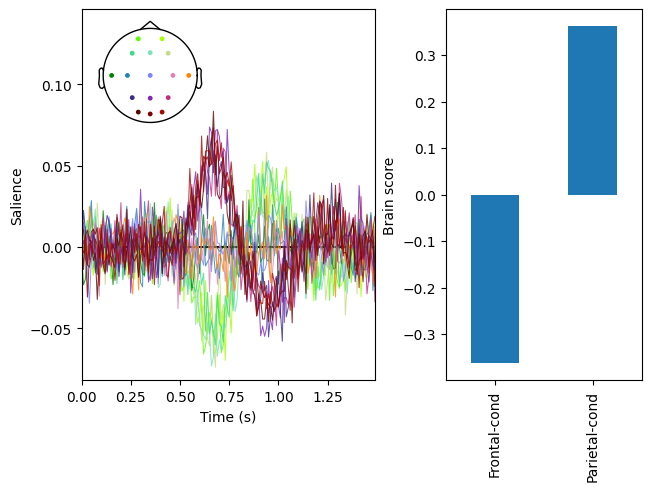

In [68]:
res = mne_plsc.fit_mc(data=evoked_list,
                      design=design,
                      within='within',
                      participant='participant',
                      random_state=123)
res.plot_lv(0)

Because this is simulated data, we will omit permutation testing and cluster analysis and instead plot the marginal brain scores to show that the model reflects how the data was simulated.

(<Figure size 640x480 with 3 Axes>,
 array([[<Axes: title={'center': 'Frontal-cond'}>,
         <Axes: title={'center': 'Parietal-cond'}>]], dtype=object))

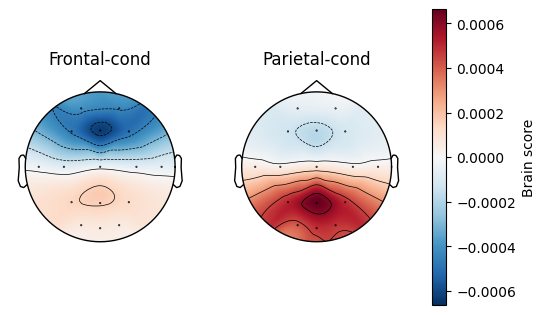

In [69]:
res.plot_marginal_brain_scores(lv_idx=0, margin='chan')

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Time (s)', ylabel='Brain score'>)

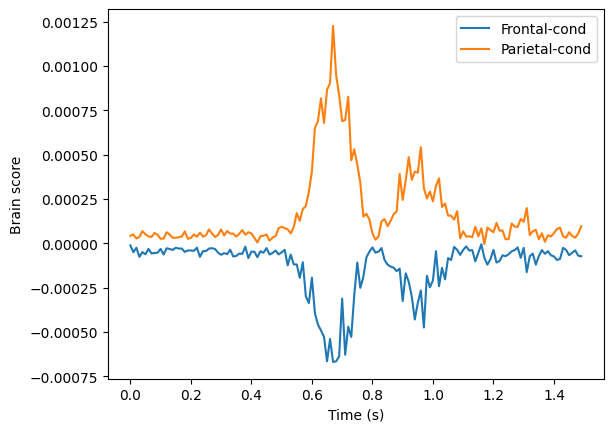

In [70]:
res.plot_marginal_brain_scores(lv_idx=0, margin='time')